# SSP uncertainties from `jax.hessian`

This notebook demos another use-case of autodiff: estimating SPP uncertainties using `jax.hessian`. This is implemented in `IntegratedSynthesizer.estimate_uncertaintites_from_hessian`.

We'd like to compare these to uncertainties from Monte Carlo simulations. The Hessian-based uncertainties, however, aren't comparable to the MC simulations performed by `IntegratedSynthesizer.synthesize_nsim`. The difference is that the MC simulations give each stellar template a unique offset in stellar parameters, while the Hessian approximation assumes that all templates are systematically offset by the same amount per simulation.

It might be possible to adjust the Hessian-based uncertainties to account for this difference. For now, to have a comparison, I've implemented another set of MC simulations (`IntegratedSynthesizer.synthesize_nsim_systematic`) which make the same assumption. The Hessian-based estimates of these mean uncertainties match the MC simulations well.

In [ ]:
from fastar.imf.named_imf.single_power_law import single_power_law as unimodal
from fastar.integrated_ssp import IntegratedSynthesizer
from matplotlib import pyplot as plt

# Then load the SSP synthesizer with that IMF
ssp_spec = IntegratedSynthesizer(imf_function=unimodal)

# Now you can generate SSP models for any age, metallicity and IMF slope
age = 11.
met = 0.0
imf_slope = 2.3

# Get Hessian-based uncertaintites
sigma_logg, sigma_teff, sigma_met = ssp_spec.estimate_uncertaintites_from_hessian(
    age=age, met=met, imf_params={'alpha': imf_slope}
)

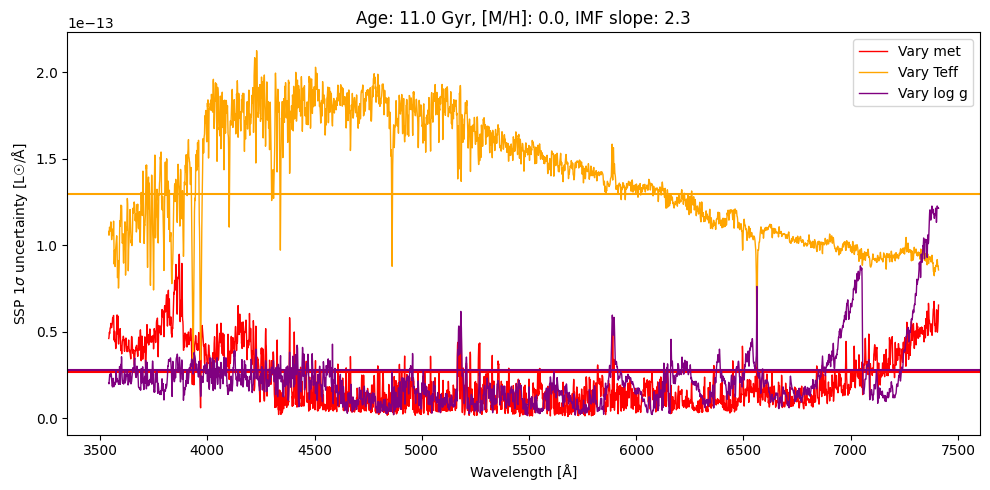

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))

# vary met
wave, std = ssp_spec.synthesize_nsim_systematic(
    age=age, met=met, imf_params={'alpha': imf_slope}, nsim=50, dlogg=0., dteff=0.
)
ax.plot(wave, std, label="Vary met", color='r', lw=1)
ax.axhline(sigma_met, color='r')

# vary teff
wave, std = ssp_spec.synthesize_nsim_systematic(
    age=age, met=met, imf_params={'alpha': imf_slope}, nsim=50, dlogg=0., dmet=0.
)
ax.plot(wave, std, label="Vary Teff", color='orange', lw=1)
ax.axhline(sigma_teff, color='orange')

# vary log g
wave, std = ssp_spec.synthesize_nsim_systematic(
    age=age, met=met, imf_params={'alpha': imf_slope}, nsim=50, dteff=0., dmet=0.
)
ax.plot(wave, std, label="Vary log g", color='purple', lw=1)
ax.axhline(sigma_logg, color='purple')

ax.legend()
ax.set_xlabel('Wavelength [Å]')
ax.set_ylabel('SSP 1$\sigma$ uncertainty [L☉/Å]')
ax.set_title(f"Age: {age} Gyr, [M/H]: {met}, IMF slope: {imf_slope}")

fig.tight_layout()